# Notebook 3: AT/RT Deep Dive — ZMYM3 Characterization

This notebook provides a detailed characterization of ZMYM3 as a
context-specific fitness gene in Atypical Teratoid/Rhabdoid Tumor (AT/RT),
including bulk expression analysis and co-dependency exploration.

**Contents:**
1. ZMYM3 dependency profile in AT/RT vs. all other indications
2. Bulk RNA-seq expression of ZMYM3 across cancer types (CCLE)
3. Co-dependency analysis to identify functionally related genes

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from adjustText import adjust_text
import os
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 150,
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'figure.facecolor': 'white',
})

DATA_DIR = '../../data'
FIG_DIR = '../../figures/depmap_analysis'
os.makedirs(FIG_DIR, exist_ok=True)

In [ ]:
# ── Load data ─────────────────────────────────────────────
gene_effect = pd.read_csv(
    os.path.join(DATA_DIR, 'gene_effect_annotated.csv'), index_col=0
)
indications = gene_effect['indication']
scores = gene_effect.drop(columns=['indication'])

# Load AT/RT specific results from Notebook 2
atrt_results = pd.read_csv(os.path.join(DATA_DIR, '02_atrt_all_gene_results.csv'))

# Identify AT/RT indication
atrt_keywords = ['rhabdoid', 'atrt', 'teratoid']
ATRT_KEY = None
for ind in indications.unique():
    if any(kw in str(ind).lower() for kw in atrt_keywords):
        ATRT_KEY = ind
        break

print(f'AT/RT indication: {ATRT_KEY}')
print(f'AT/RT cell lines: {(indications == ATRT_KEY).sum()}')

AT/RT indication: Atypical Teratoid/Rhabdoid Tumor
AT/RT cell lines: 16


## 3.1 ZMYM3 Dependency Profile (Figure S2)

Detailed examination of ZMYM3 dependency specifically in AT/RT cell lines
compared to all other cancer types.

In [ ]:
# ── ZMYM3 per-cell-line dependency ────────────────────────
TARGET_GENE = 'ZMYM3'
DEPENDENCY_CUTOFF = -0.6

zmym3_scores = scores[TARGET_GENE].dropna()
zmym3_indications = indications[zmym3_scores.index]

atrt_scores = zmym3_scores[zmym3_indications == ATRT_KEY]
other_scores = zmym3_scores[zmym3_indications != ATRT_KEY]

print(f'ZMYM3 Dependency Summary')
print(f'═══════════════════════════════════════════')
print(f'AT/RT cell lines (N={len(atrt_scores)}):')
print(f'  Mean score:    {atrt_scores.mean():.4f}')
print(f'  Median score:  {atrt_scores.median():.4f}')
print(f'  Min score:     {atrt_scores.min():.4f}')
print(f'  Max score:     {atrt_scores.max():.4f}')
print(f'  Fraction dependent (≤{DEPENDENCY_CUTOFF}): '
      f'{(atrt_scores <= DEPENDENCY_CUTOFF).mean():.1%}')
print(f'\nAll other cell lines (N={len(other_scores)}):')
print(f'  Mean score:    {other_scores.mean():.4f}')
print(f'  Median score:  {other_scores.median():.4f}')
print(f'  Fraction dependent (≤{DEPENDENCY_CUTOFF}): '
      f'{(other_scores <= DEPENDENCY_CUTOFF).mean():.1%}')
print(f'\nDelta mean (AT/RT − other): {atrt_scores.mean() - other_scores.mean():.4f}')

ZMYM3 Dependency Summary
═══════════════════════════════════════════
AT/RT cell lines (N=16):
  Mean score:    -0.6265
  Median score:  -0.6570
  Min score:     -1.2390
  Max score:     -0.0689
  Fraction dependent (≤-0.6): 56.2%

All other cell lines (N=1192):
  Mean score:    -0.1393
  Median score:  -0.1346
  Fraction dependent (≤-0.6): 2.9%

Delta mean (AT/RT − other): -0.4872


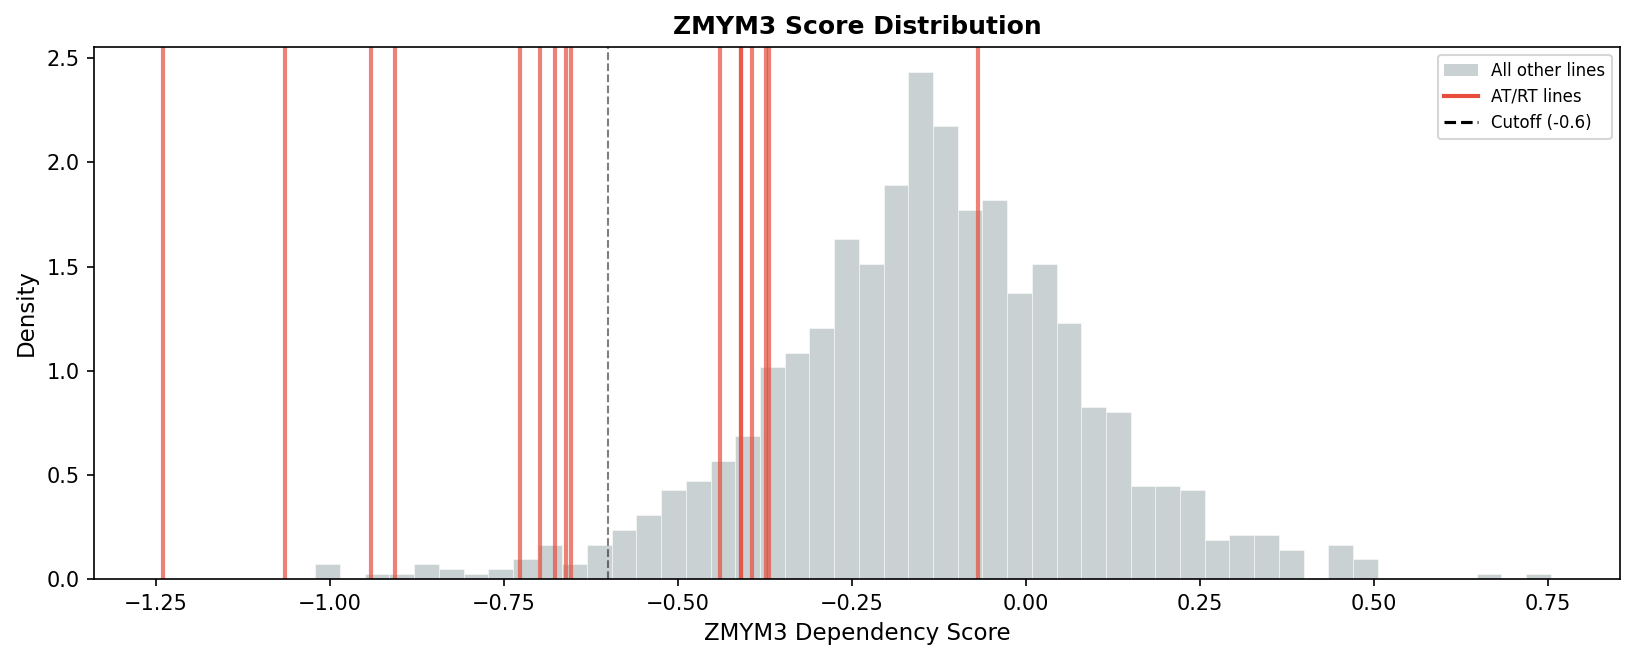

Saved: figS2_ZMYM3_atrt_scores.pdf/png


In [ ]:
# ── Figure S2: ZMYM3 score distributions ────────────────────
fig, ax = plt.subplots(1, 1, figsize=(11, 4.5))

# Panel A: Histogram comparison
ax.hist(other_scores, bins=50, alpha=0.5, color='#95a5a6', label='All other',
        density=True, edgecolor='white', linewidth=0.5)
for s in atrt_scores:
    ax.axvline(s, color='#e74c3c', alpha=0.7, linewidth=2)
ax.axvline(DEPENDENCY_CUTOFF, color='black', linestyle='--', linewidth=1,
           alpha=0.5, label=f'Cutoff ({DEPENDENCY_CUTOFF})')
ax.set_xlabel(f'{TARGET_GENE} Dependency Score')
ax.set_ylabel('Density')
ax.set_title(f'{TARGET_GENE} Score Distribution', fontweight='bold')

# Custom legend
from matplotlib.lines import Line2D
legend_elements = [
    mpatches.Patch(facecolor='#95a5a6', alpha=0.5, label='All other lines'),
    Line2D([0], [0], color='#e74c3c', linewidth=2, label='AT/RT lines'),
    Line2D([0], [0], color='black', linestyle='--', label=f'Cutoff ({DEPENDENCY_CUTOFF})'),
]
ax.legend(handles=legend_elements, fontsize=8)

fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, f'figS2_{TARGET_GENE}_atrt_scores.pdf'), bbox_inches='tight')
fig.savefig(os.path.join(FIG_DIR, f'figS2_{TARGET_GENE}_atrt_scores.png'), dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: figS2_{TARGET_GENE}_atrt_scores.pdf/png')

## 3.2 Bulk RNA-seq Expression of ZMYM3 from CCLE (Figure 2b)

Examine ZMYM3 transcript expression across cancer types using CCLE
RNA-seq data (if available).

Download `OmicsExpressionProteinCodingGenesTPMLogp1.csv` from DepMap
and place in `../data/`.

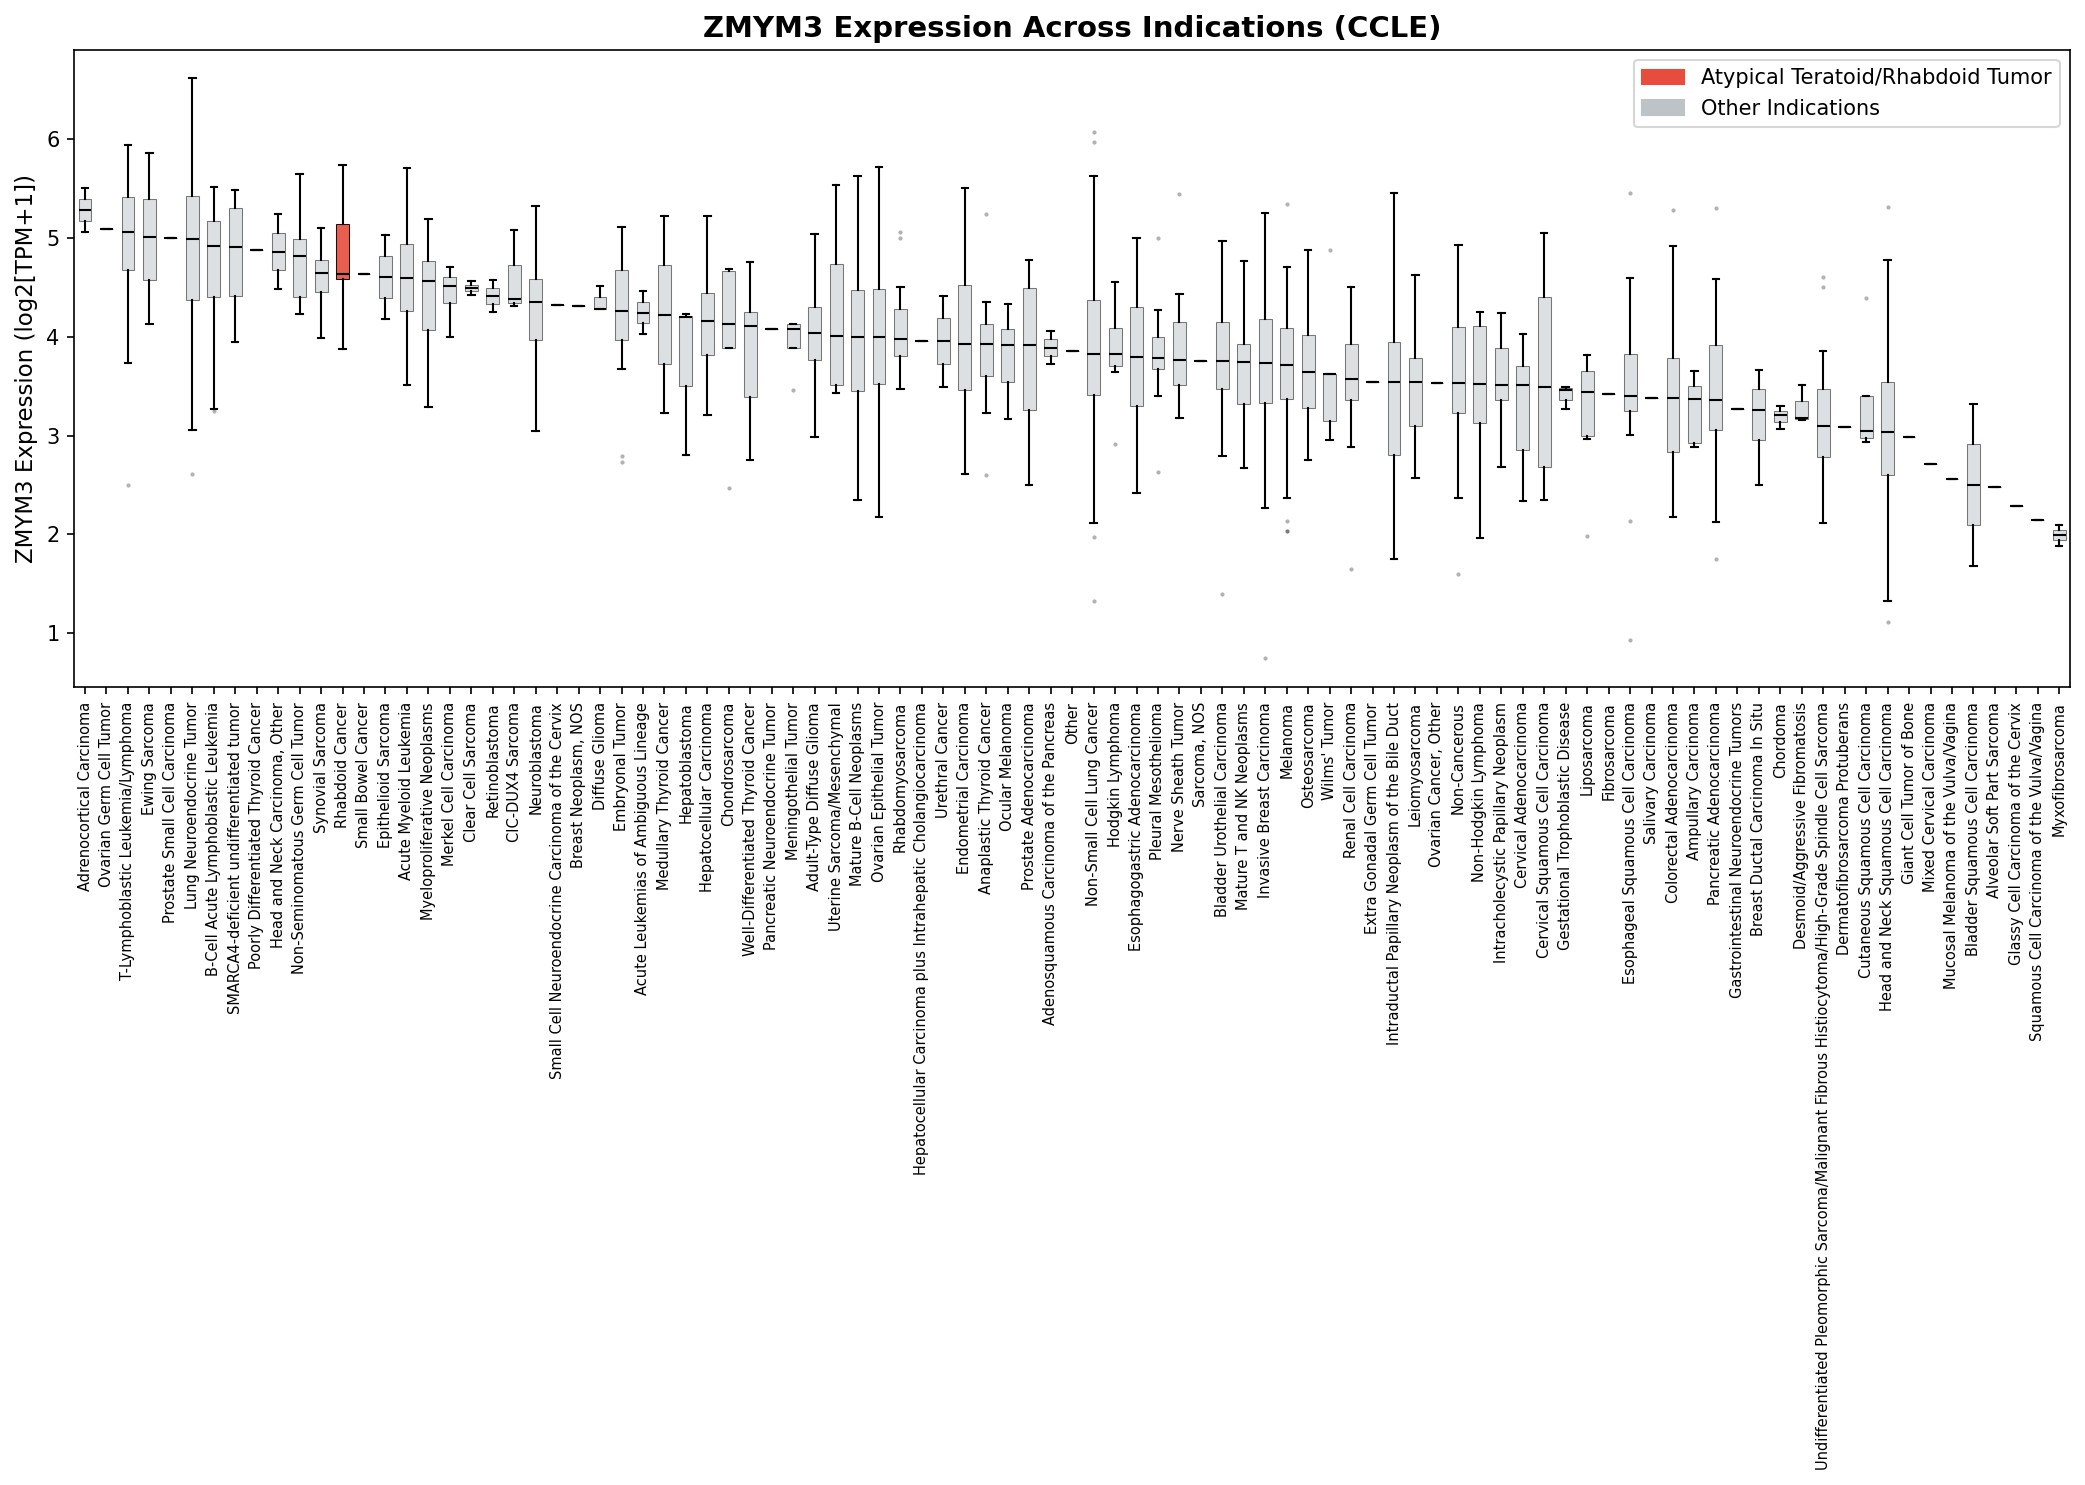

AT/RT Median Expression: 4.6375
Global Median Expression: 3.8845


In [ ]:
# ── Load CCLE expression data ─────────────────────────────────
EXPR_FILE = os.path.join(DATA_DIR, 'OmicsExpressionTPMLogp1HumanProteinCodingGenes.csv')
MODEL_FILE = os.path.join(DATA_DIR, 'Model.csv')

if os.path.exists(EXPR_FILE) and os.path.exists(MODEL_FILE):
    expression = pd.read_csv(EXPR_FILE, index_col=0)
    model_info = pd.read_csv(MODEL_FILE)

    # The first few columns are metadata (ProfileID, is_default_entry, ModelID)
    # We need to map ProfileID (index) to ModelID then to Indication
    if 'ModelID' in expression.columns:
        # Some versions have ModelID as a column
        id_mapping = expression['ModelID'].to_dict()
        # Remove metadata columns to keep only genes for the search
        gene_cols = [c for c in expression.columns if c not in ['ModelID', 'is_default_entry', 'ProfileID']]
    else:
        # If ModelID isn't a column, we assume index is ProfileID or ModelID
        # and we use the Model.csv to map
        id_mapping = {idx: idx for idx in expression.index}
        gene_cols = expression.columns

    # Create ModelID -> Indication mapping from Model.csv
    # We use 'OncotreePrimaryDisease' as it best matches the 'indication' used previously
    ind_col = 'OncotreePrimaryDisease'
    if ind_col not in model_info.columns:
        ind_col = 'OncotreeLineage'

    model_to_ind = model_info.set_index('ModelID')[ind_col].to_dict()

    # Identify the gene column
    expr_genes = {c.split(' (')[0]: c for c in gene_cols if ' (' in c}

    if TARGET_GENE in expr_genes:
        zmym3_col = expr_genes[TARGET_GENE]

        # Build a clean dataframe of expression and indications
        plot_list = []
        for idx, val in expression[zmym3_col].items():
            model_id = id_mapping.get(idx, idx)
            indication = model_to_ind.get(model_id, 'Unknown')
            plot_list.append({'expression': val, 'indication': indication})

        expr_df = pd.DataFrame(plot_list)
        expr_df = expr_df[expr_df['indication'] != 'Unknown']

        # Standardize ATRT_KEY lookup to ensure match
        # The expression data might use 'Atypical Teratoid Rhabdoid Tumor' vs '.../Rhabdoid...'
        current_atrt_key = None
        available_inds = expr_df['indication'].unique()
        for ind in available_inds:
            if any(kw in str(ind).lower() for kw in atrt_keywords):
                current_atrt_key = ind
                break

        # Group data for plotting
        grouped_data = expr_df.groupby('indication')['expression'].apply(list)
        medians = expr_df.groupby('indication')['expression'].median().sort_values(ascending=False)
        order = medians.index

        # Plot
        fig, ax = plt.subplots(figsize=(14, 10))
        data_to_plot = [grouped_data[ind] for ind in order]

        bp = ax.boxplot(
            data_to_plot,
            labels=order, vert=True, patch_artist=True, widths=0.6,
            boxprops=dict(linewidth=0.5),
            medianprops=dict(color='black', linewidth=1),
            flierprops=dict(marker='.', markersize=2, alpha=0.3),
        )

        for i, (ind, patch) in enumerate(zip(order, bp['boxes'])):
            if current_atrt_key and ind == current_atrt_key:
                patch.set_facecolor('#e74c3c')
                patch.set_alpha(0.9)
            else:
                patch.set_facecolor('#bdc3c7')
                patch.set_alpha(0.5)

        # Add legend
        atrt_patch = mpatches.Patch(color='#e74c3c', label=f'Atypical Teratoid/Rhabdoid Tumor')
        other_patch = mpatches.Patch(color='#bdc3c7', label='Other Indications')
        ax.legend(handles=[atrt_patch, other_patch], loc='upper right')

        ax.set_xticklabels(order, rotation=90, fontsize=7)
        ax.set_ylabel(f'{TARGET_GENE} Expression (log2[TPM+1])')
        ax.set_title(f'{TARGET_GENE} Expression Across Indications (CCLE)', fontweight='bold',  fontsize=14)

        fig.tight_layout()
        fig.savefig(os.path.join(FIG_DIR, f'fig2b_{TARGET_GENE}_expression.pdf'), bbox_inches='tight')
        fig.savefig(os.path.join(FIG_DIR, f'fig2b_{TARGET_GENE}_expression.png'), bbox_inches='tight', dpi=300)
        plt.show()

        if current_atrt_key:
            atrt_median = expr_df[expr_df['indication'] == current_atrt_key]['expression'].median()
            overall_median = expr_df['expression'].median()
            print(f'AT/RT Median Expression: {atrt_median:.4f}')
            print(f'Global Median Expression: {overall_median:.4f}')
    else:
        print(f'{TARGET_GENE} column not found in expression matrix.')
else:
    print('Missing required files (OmicsExpression... or Model.csv) in DATA_DIR.')

## 3.3 Co-Dependency Analysis (Figure 3)

Identify genes whose dependency profiles correlate with ZMYM3 across
all cell lines. Genes with correlated fitness profiles often participate
in the same functional pathway or protein complex, so we particularly search for CoREST members and SWI/SNF genes.

In [ ]:
# ── Co-dependency: Pearson correlations with ZMYM3 ───────
if TARGET_GENE in scores.columns:
    zmym3_profile = scores[TARGET_GENE]

    # Compute correlations with all other genes
    correlations = []
    for gene in scores.columns:
        if gene == TARGET_GENE:
            continue
        both = pd.DataFrame({'zmym3': zmym3_profile, 'other': scores[gene]}).dropna()
        if len(both) < 50:  # need adequate overlap
            continue
        r, p = stats.pearsonr(both['zmym3'], both['other'])
        correlations.append({'gene': gene, 'pearson_r': r, 'p_value': p})

    corr_df = pd.DataFrame(correlations)
    corr_df = corr_df.sort_values('pearson_r', ascending=False)

    print(f'Computed correlations for {len(corr_df)} genes.')
    print(f'\nTop 20 positively co-dependent genes with {TARGET_GENE}:')
    print(corr_df.head(20)[['gene', 'pearson_r', 'p_value']].to_string(index=False))

    print(f'\nTop 20 negatively co-dependent genes with {TARGET_GENE}:')
    print(corr_df.tail(20)[['gene', 'pearson_r', 'p_value']].to_string(index=False))

    # Check for CoREST complex members and SWI/SNF genes
    corest_genes = ['RCOR1', 'RCOR2', 'KDM1A', 'HDAC1', 'HDAC2',
                    'HMG20B', 'PHF21A', 'GSE1', 'ZMYM2', 'ZMYM4']
    swi_snf_genes = ['SMARCB1', 'SMARCA4', 'SMARCA2', 'ARID1A', 'ARID1B',
                     'SMARCC1', 'SMARCC2', 'SMARCD1', 'DPF2']

    print(f'\nCoREST complex gene correlations with {TARGET_GENE}:')
    corest_corrs = corr_df[corr_df['gene'].isin(corest_genes)]
    if len(corest_corrs) > 0:
        print(corest_corrs[['gene', 'pearson_r', 'p_value']].to_string(index=False))
    else:
        print('  No CoREST genes found.')

    print(f'\nSWI/SNF complex gene correlations with {TARGET_GENE}:')
    swisnf_corrs = corr_df[corr_df['gene'].isin(swi_snf_genes)]
    if len(swisnf_corrs) > 0:
        print(swisnf_corrs[['gene', 'pearson_r', 'p_value']].to_string(index=False))
    else:
        print('  No SWI/SNF genes found.')

    # Save
    corr_df.to_csv(os.path.join(DATA_DIR, f'03_{TARGET_GENE}_codependencies.csv'), index=False)
    print(f'\nSaved: 03_{TARGET_GENE}_codependencies.csv')

Computed correlations for 18434 genes.

Top 20 positively co-dependent genes with ZMYM3:
     gene  pearson_r      p_value
   H2BC12   0.385030 9.973845e-04
   ZNF595   0.371058 1.135351e-03
   GTPBP6   0.361401 1.558166e-03
  C4orf54   0.360568 1.726456e-03
 C13orf42   0.344395 3.506958e-03
   CCDC57   0.343162 2.248111e-03
  TMEM272   0.328890 5.436933e-03
   FIGNL2   0.313204 6.584860e-03
 TMEM132C   0.302242 7.549629e-03
  SLC35F4   0.292093 9.947279e-03
  C3orf85   0.287504 1.580828e-02
    SPEM3   0.286035 1.637572e-02
   HIGD2B   0.285316 1.441479e-02
C17orf100   0.284779 1.206400e-02
    GSTT4   0.282531 1.779962e-02
    IL3RA   0.278216 1.638836e-02
  MINDY4B   0.259426 3.010501e-02
    PRAC2   0.249056 3.236872e-02
   TRIM48   0.246239 3.444278e-02
      RLF   0.240886 2.085336e-17

Top 20 negatively co-dependent genes with ZMYM3:
      gene  pearson_r  p_value
   C2orf92  -0.212458 0.077436
     OR6J1  -0.212737 0.070762
    PRR20G  -0.216641 0.071644
     NUDT4  -0.220046 0

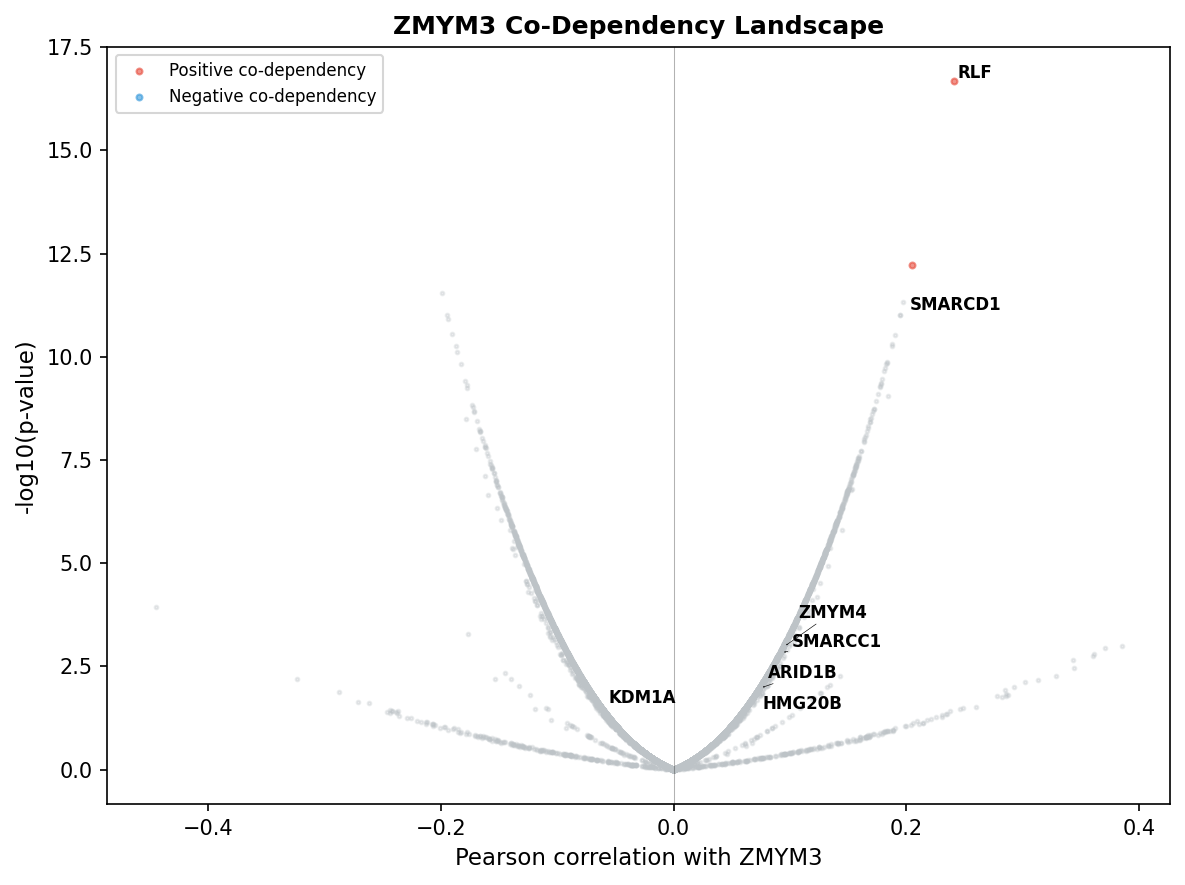

Saved: fig3_ZMYM3_codep_volcano.pdf/png


In [ ]:
# ── Figure 3: Co-dependency volcano plot ───────────────────
if TARGET_GENE in scores.columns:
    fig, ax = plt.subplots(figsize=(8, 6))

    x = corr_df['pearson_r']
    y = -np.log10(corr_df['p_value'].clip(lower=1e-300))

    # Color by significance
    sig_mask = (corr_df['p_value'] < 1e-10) & (corr_df['pearson_r'].abs() > 0.2)

    ax.scatter(x[~sig_mask], y[~sig_mask], c='#bdc3c7', s=3, alpha=0.3)
    ax.scatter(x[sig_mask & (x > 0)], y[sig_mask & (x > 0)],
               c='#e74c3c', s=8, alpha=0.6, label='Positive co-dependency')
    ax.scatter(x[sig_mask & (x < 0)], y[sig_mask & (x < 0)],
               c='#3498db', s=8, alpha=0.6, label='Negative co-dependency')

    # Label CoREST and SWI/SNF genes
    # highlight genes including corest_genes, swi_snf_genes, and the highest, RLF
    highlight_genes = ['SMARCD1', 'SMARCC1', 'ZMYM4', 'HMG20B', 'KDM1A', 'ARID1B', 'RLF']

    texts = []
    for _, row in corr_df[corr_df['gene'].isin(highlight_genes)].iterrows():
        texts.append(ax.text(row['pearson_r'], -np.log10(max(row['p_value'], 1e-300)),
                             row['gene'], fontsize=8, fontweight='bold'))

    # Adjust labels to prevent overlaps
    adjust_text(texts, arrowprops=dict(arrowstyle='->', color='black', lw=0.3))

    ax.set_xlabel(f'Pearson correlation with {TARGET_GENE}')
    ax.set_ylabel(f'-log10(p-value)')
    ax.set_title(f'{TARGET_GENE} Co-Dependency Landscape', fontweight='bold')
    ax.legend(fontsize=8)
    ax.axvline(0, color='black', linewidth=0.5, alpha=0.3)

    fig.tight_layout()
    fig.savefig(os.path.join(FIG_DIR, f'fig3_{TARGET_GENE}_codep_volcano.pdf'), bbox_inches='tight')
    fig.savefig(os.path.join(FIG_DIR, f'fig3_{TARGET_GENE}_codep_volcano.png'), dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Saved: fig3_{TARGET_GENE}_codep_volcano.pdf/png')